In [1]:
from google.colab import files

uploaded = files.upload()




Saving Twitter_Data (1).csv to Twitter_Data (1).csv


In [2]:
import pandas as pd

df = pd.read_csv("Twitter_Data (1).csv")

print(df.shape)
print(df.columns)
print(df.head())


(162975, 1)
Index(['clean_text'], dtype='object')
                                          clean_text
0  when modi promised “minimum government maximum...
1  talk all the nonsense and continue all the dra...
2  what did just say vote for modi  welcome bjp t...
3  asking his supporters prefix chowkidar their n...
4  answer who among these the most powerful world...


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
clean_text    0
dtype: int64

Duplicate rows:
1


In [4]:
df = df.drop_duplicates()

print(df.shape)

(162974, 1)


In [5]:
df.to_csv("processed_data.csv", index=False)

print("Preprocessing completed successfully!")


Preprocessing completed successfully!


In [6]:
df = df.dropna()
df = df.drop_duplicates()

df["clean_text"] = df["clean_text"].str.strip()

print(df.shape)

(162974, 1)


In [7]:
df.to_csv("processed_data.csv", index=False)

print("Preprocessing completed!")

Preprocessing completed!


In [10]:
!pip install transformers torch -q

In [11]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

print(
    classifier(
        "I love this project"
    )
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999884843826294}]


In [12]:
sample_df = df.sample(1000, random_state=42)

sample_df["sentiment"] = sample_df["clean_text"].apply(
    lambda x: classifier(str(x)[:512])[0]["label"]
)

sample_df.head()


,clean_text,sentiment
161515,cant work like modi yogi next,POSITIVE
149429,gandhi family chor thi hai agar sarkar aayi th...,NEGATIVE
5215,why modi not taking pok back,NEGATIVE
33604,actually mmj should allowed contest and cut in...,NEGATIVE
155301,when modi brought attention the plight tribals...,NEGATIVE


In [13]:
sample_df["sentiment"].value_counts()

,count
sentiment,
NEGATIVE,657
POSITIVE,343


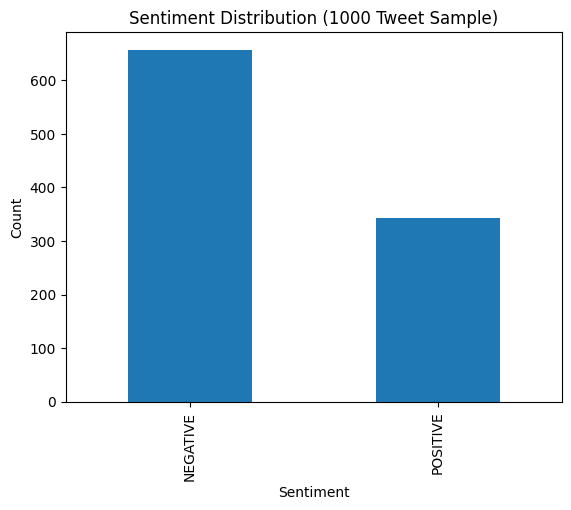

In [14]:
import matplotlib.pyplot as plt

sample_df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution (1000 Tweet Sample)")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [16]:
!pip install transformers torch -q

In [17]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [18]:
print(classifier("I love this movie"))
print(classifier("This movie is okay"))
print(classifier("I hate this movie"))

[{'label': 'positive', 'score': 0.9674931764602661}]
[{'label': 'positive', 'score': 0.8669659495353699}]
[{'label': 'negative', 'score': 0.8983777165412903}]


In [19]:
print(classifier("The meeting is scheduled for tomorrow"))
print(classifier("India won the match"))
print(classifier("The product was delivered today"))
print(classifier("I neither like nor dislike this"))

[{'label': 'neutral', 'score': 0.9468417763710022}]
[{'label': 'positive', 'score': 0.5615063905715942}]
[{'label': 'positive', 'score': 0.8154169917106628}]
[{'label': 'negative', 'score': 0.5617188215255737}]


In [20]:
sample_10k = df.sample(10000, random_state=42)

sample_10k["sentiment"] = sample_10k["clean_text"].apply(
    lambda x: classifier(str(x)[:512])[0]["label"]
)

sample_10k["sentiment"].value_counts()

KeyboardInterrupt: 

In [ ]:
sample_10k = df.sample(10000, random_state=42)

texts = sample_10k["clean_text"].astype(str).tolist()

results = classifier(
    texts,
    batch_size=64,
    truncation=True
)

sample_10k["sentiment"] = [
    r["label"] for r in results
]

sample_10k["sentiment"].value_counts()

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=0
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [4]:
sample_1k = df.sample(1000, random_state=42)

texts = sample_1k["clean_text"].astype(str).tolist()

results = classifier(
    texts,
    batch_size=128,
    truncation=True
)

sample_1k["sentiment"] = [r["label"] for r in results]

print(sample_1k["sentiment"].value_counts())

NameError: name 'df' is not defined

In [6]:
import pandas as pd

df = pd.read_csv("Twitter_Data (1).csv")

print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Twitter_Data (1).csv'

In [7]:
import pandas as pd

df = pd.read_csv("Twitter_Data (1).csv")

print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'Twitter_Data (1).csv'

In [8]:
!ls -lh


total 35M
drwxr-xr-x 1 root root 4.0K Jun  4 13:39  sample_data
-rw-r--r-- 1 root root  20M Jun 15 15:45 'Twitter_Data (1).csv'
-rw-r--r-- 1 root root  15M Jun 15 15:44  Twitter_Data.csv


In [9]:
import pandas as pd

df = pd.read_csv("/content/Twitter_Data.csv")

print(df.shape)

(124419, 1)


In [10]:
import pandas as pd

df = pd.read_csv("Twitter_Data.csv", sep="\t")

print(df.shape)
print(df.head())


(124419, 1)
                                          clean_text
0  when modi promised “minimum government maximum...
1  talk all the nonsense and continue all the dra...
2  what did just say vote for modi  welcome bjp t...
3  asking his supporters prefix chowkidar their n...
4  answer who among these the most powerful world...


In [11]:
classifier("I love India")

[{'label': 'positive', 'score': 0.9523592591285706}]

In [12]:
sample_1k = df.sample(1000, random_state=42)

texts = sample_1k["clean_text"].astype(str).tolist()

results = classifier(
    texts,
    batch_size=128,
    truncation=True
)

sample_1k["sentiment"] = [r["label"] for r in results]

print(sample_1k["sentiment"].value_counts())

sentiment
neutral     467
negative    370
positive    163
Name: count, dtype: int64


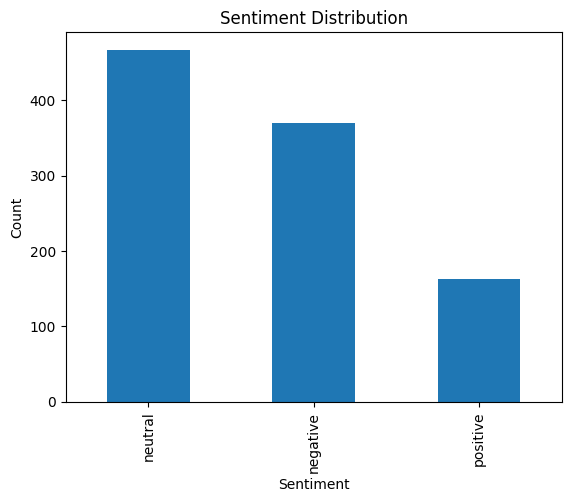

In [13]:
import matplotlib.pyplot as plt

sample_1k["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [14]:
batch_size = 5000

all_sentiments = []

for i in range(0, len(df), batch_size):

    texts = df["clean_text"].iloc[i:i+batch_size].astype(str).tolist()s

    results = classifier(
        texts,
        batch_size=128,
        truncation=True
    )

    all_sentiments.extend([r["label"] for r in results])

    print(f"Processed {i + len(texts)} / {len(df)}")

Processed 5000 / 124419
Processed 10000 / 124419
Processed 15000 / 124419
Processed 20000 / 124419
Processed 25000 / 124419
Processed 30000 / 124419
Processed 35000 / 124419


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 40000 / 124419
Processed 45000 / 124419
Processed 50000 / 124419
Processed 55000 / 124419
Processed 60000 / 124419
Processed 65000 / 124419
Processed 70000 / 124419
Processed 75000 / 124419
Processed 80000 / 124419
Processed 85000 / 124419
Processed 90000 / 124419
Processed 95000 / 124419
Processed 100000 / 124419
Processed 105000 / 124419
Processed 110000 / 124419
Processed 115000 / 124419
Processed 120000 / 124419
Processed 124419 / 124419


In [15]:
df["sentiment"] = all_sentiments

print(df["sentiment"].value_counts())

sentiment
neutral     58367
negative    46608
positive    19444
Name: count, dtype: int64


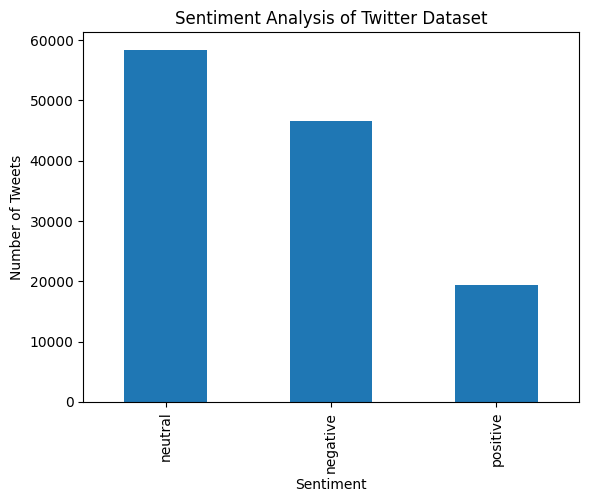

In [16]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Analysis of Twitter Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [18]:
df.to_csv("twitter_sentiment_results.csv", index=False)

In [19]:
import os
print(os.listdir())

['.config', 'Twitter_Data (1).csv', 'Twitter_Data.csv', 'twitter_sentiment_results.csv', 'sample_data']


In [20]:
!ls


 sample_data		 Twitter_Data.csv
'Twitter_Data (1).csv'	 twitter_sentiment_results.csv


In [21]:
from google.colab import files
files.download("twitter_sentiment_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>